# AdaPP Control Panel

End-to-end notebook for **"Online Informative Path Planning using Sparse Gaussian Processes"** (Mishra et al. 2018).

Runs AdaPP (with both SPGP/FITC and SVGP backends) vs lawnmower baseline on OceanBench data.

**Sections:**
1. Configuration
2. Setup & imports
3. Load data (DataProvider or synthetic fallback)
4. Build grid and cell decomposition
5. Show truth map
6. Run SPGP on initial observations
7. Run AdaPP for multiple time budgets (both backends)
8. Run lawnmower baseline
9. Results: trajectory, pred/uncertainty, error, RMSE vs T
10. Save results

## 1. Configuration

In [1]:
# ===== EDIT THIS BLOCK =====

PRODUCT_ID = "copernicus_phy_reanalysis_001_030"
REGION = {"lon": [-92, -86], "lat": [22, 28]}
TIME_WINDOW = ("2014-01-01", "2014-01-07")
VARIABLE = "temp"

# Grid
N_LAT, N_LON = 15, 15
CONNECTIVITY = "4"
SPEED_MPS = 1.0

# Cell decomposition
N_CELL_LAT, N_CELL_LON = 8, 8
INITIAL_VARIANCE = 1.0  # kappa

# AdaPP parameters
GAMMA = 0.9
ETA = 0.5
NOISE_VAR = 0.01
N_PSEUDO = 30
REFIT_INTERVAL = 2

# Time budgets (seconds) — paper uses T in {600, 800, 1000, 1200}
TIME_BUDGETS = [10, 20, 30, 40, 50]

# Truth mode
TRUTH_MODE = "static"  # static | dynamic_provider
STATIC_TIME_INDEX = 0

# Eval grid
EVAL_RES = 40  # per axis (capped to 10000 total)

SEED = 42

# =============================

## 2. Setup & Imports

In [2]:
import sys, warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for pkg in [
    "oceanbench-core", "oceanbench-models", "oceanbench-env",
    "oceanbench-policies", "oceanbench-data-provider", "oceanbench-viz",
    "oceanbench-tasks", "oceanbench-bench",
]:
    d = ROOT / pkg
    if d.exists() and str(d) not in sys.path:
        sys.path.insert(0, str(d))

import numpy as np
import matplotlib.pyplot as plt

from oceanbench_core.types import ObservationBatch, QueryPoints
from oceanbench_core import WaypointGraph
from oceanbench_core.cell_decomposition import CellGrid

rng = np.random.default_rng(SEED)
print("Imports OK")

Imports OK


## 3. Load Data

In [3]:
region_dict = {
    "lat_min": REGION["lat"][0], "lat_max": REGION["lat"][1],
    "lon_min": REGION["lon"][0], "lon_max": REGION["lon"][1],
}

USE_REAL_DATA = False
truth_field_obj = None

try:
    from oceanbench_data_provider import DataProvider
    from oceanbench_env import OceanTruthField
    provider = DataProvider()
    truth_ds = provider.get_subset(
        product_id=PRODUCT_ID, variables=[VARIABLE],
        region=region_dict,
        time_range=(np.datetime64(TIME_WINDOW[0]), np.datetime64(TIME_WINDOW[1])),
    )
    truth_field_obj = OceanTruthField(dataset=truth_ds, variable=VARIABLE)
    USE_REAL_DATA = True
    print(f"Loaded real data: {truth_ds}")
except Exception as e:
    print(f"DataProvider unavailable ({e}), using synthetic fallback.")

def _synth_field(lat, lon):
    return 22.0 + 3.0 * np.sin(0.8 * (lat - region_dict['lat_min'])) + 2.5 * np.cos(0.6 * (lon - region_dict['lon_min']))

# Eval grid (capped to 10000).
eval_res = min(EVAL_RES, int(np.sqrt(10000)))
eval_lats = np.linspace(region_dict['lat_min'], region_dict['lat_max'], eval_res)
eval_lons = np.linspace(region_dict['lon_min'], region_dict['lon_max'], eval_res)
lat_m, lon_m = np.meshgrid(eval_lats, eval_lons, indexing='ij')
eval_lats_flat = lat_m.ravel()
eval_lons_flat = lon_m.ravel()
eval_qp = QueryPoints(lats=eval_lats_flat, lons=eval_lons_flat)

if USE_REAL_DATA:
    t_qp = QueryPoints(lats=eval_lats_flat, lons=eval_lons_flat,
                        times=np.full(len(eval_lats_flat), truth_ds.time.values[STATIC_TIME_INDEX]))
    truth_values = truth_field_obj.query_array(t_qp)
else:
    truth_values = _synth_field(eval_lats_flat, eval_lons_flat)

nan_mask = np.isnan(truth_values)
if nan_mask.any():
    truth_values[nan_mask] = np.nanmean(truth_values)
print(f"Truth: shape={truth_values.shape}, range=[{truth_values.min():.2f}, {truth_values.max():.2f}]")

DataProvider unavailable ('DataProvider' object has no attribute 'get_subset'), using synthetic fallback.
Truth: shape=(1600,), range=[16.50, 27.50]


## 4. Build Grid & Cell Decomposition

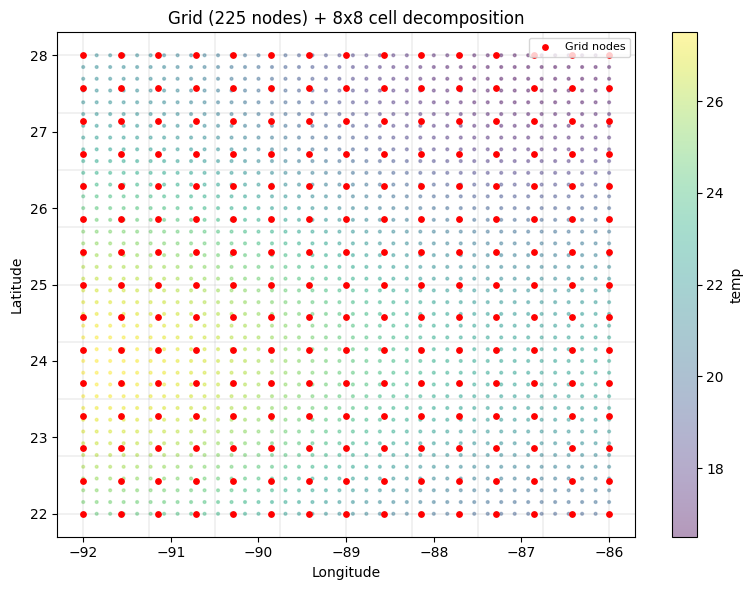

In [4]:
graph = WaypointGraph.grid(region_dict, N_LAT, N_LON, speed_mps=SPEED_MPS, connectivity=CONNECTIVITY, seed=SEED)
nodes = list(graph.graph.nodes)
node_lats = np.array([graph.graph.nodes[n]['lat'] for n in nodes])
node_lons = np.array([graph.graph.nodes[n]['lon'] for n in nodes])

cell_grid = CellGrid.from_region(region_dict, N_CELL_LAT, N_CELL_LON, node_lats, node_lons)
cell_grid.initialize(INITIAL_VARIANCE)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(eval_lons_flat, eval_lats_flat, c=truth_values, cmap='viridis', s=4, alpha=0.4)
plt.colorbar(sc, ax=ax, label=VARIABLE)
ax.scatter(node_lons, node_lats, c='red', s=15, zorder=5, label='Grid nodes')
# Draw cell boundaries.
lat_edges = np.linspace(region_dict['lat_min'], region_dict['lat_max'], N_CELL_LAT + 1)
lon_edges = np.linspace(region_dict['lon_min'], region_dict['lon_max'], N_CELL_LON + 1)
for le in lat_edges:
    ax.axhline(le, color='gray', linewidth=0.3, alpha=0.5)
for lo in lon_edges:
    ax.axvline(lo, color='gray', linewidth=0.3, alpha=0.5)
ax.set_title(f'Grid ({len(nodes)} nodes) + {N_CELL_LAT}x{N_CELL_LON} cell decomposition')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Truth Map

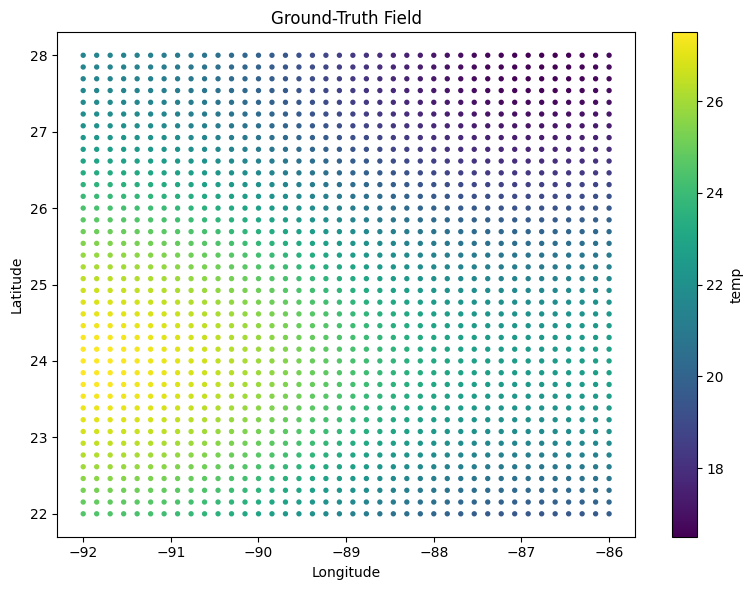

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(eval_lons_flat, eval_lats_flat, c=truth_values, cmap='viridis', s=8)
plt.colorbar(sc, ax=ax, label=VARIABLE)
ax.set_title('Ground-Truth Field')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout(); plt.show()

## 6. Run SPGP on Initial Sample

Demonstrate the paper's SPGP (FITC) model on a random initial sample.

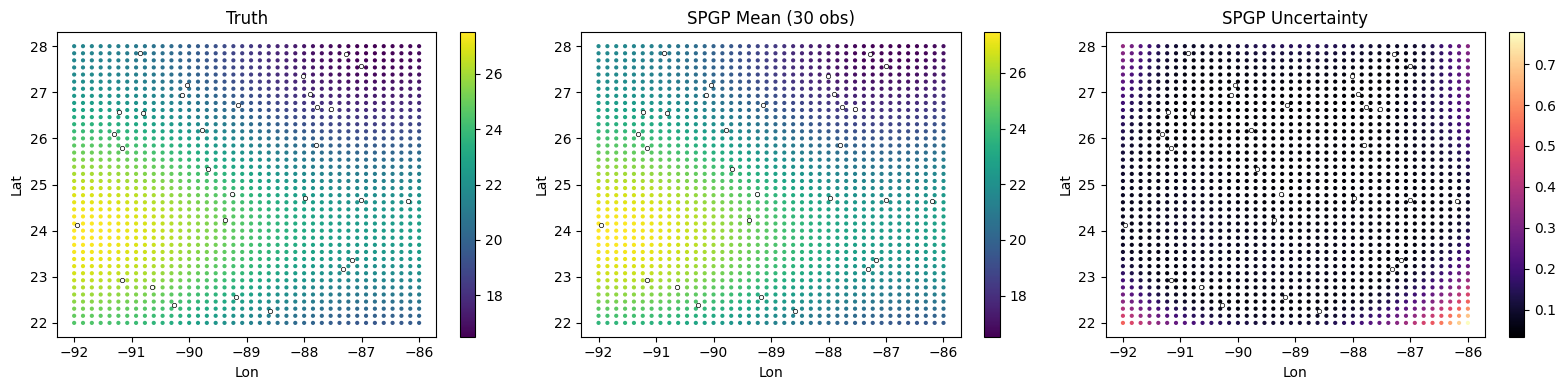

Initial SPGP RMSE: 0.1422


In [6]:
from oceanbench_models.belief.field.spgp_fitc import SPGPFITCFieldModel

n_init = 30
init_lats = rng.uniform(region_dict['lat_min'], region_dict['lat_max'], n_init)
init_lons = rng.uniform(region_dict['lon_min'], region_dict['lon_max'], n_init)
dists_init = np.linalg.norm(
    np.stack([eval_lats_flat, eval_lons_flat], axis=1)[None, :, :]
    - np.stack([init_lats, init_lons], axis=1)[:, None, :], axis=2)
init_values = truth_values[np.argmin(dists_init, axis=1)] + rng.normal(0, np.sqrt(NOISE_VAR), n_init)

init_obs = ObservationBatch(lats=init_lats, lons=init_lons, values=init_values, variable=VARIABLE)

spgp_model = SPGPFITCFieldModel({'n_pseudo': N_PSEUDO, 'max_opt_iters': 100, 'include_time': False, 'include_depth': False}, seed=SEED)
spgp_model.fit(init_obs)
pred_init = spgp_model.predict(eval_qp)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sc0 = axes[0].scatter(eval_lons_flat, eval_lats_flat, c=truth_values, cmap='viridis', s=4)
plt.colorbar(sc0, ax=axes[0]); axes[0].set_title('Truth')
sc1 = axes[1].scatter(eval_lons_flat, eval_lats_flat, c=pred_init.mean, cmap='viridis', s=4)
plt.colorbar(sc1, ax=axes[1]); axes[1].set_title(f'SPGP Mean ({n_init} obs)')
sc2 = axes[2].scatter(eval_lons_flat, eval_lats_flat, c=pred_init.std, cmap='magma', s=4)
plt.colorbar(sc2, ax=axes[2]); axes[2].set_title('SPGP Uncertainty')
for ax in axes:
    ax.scatter(init_lons, init_lats, c='white', s=10, edgecolors='black', linewidths=0.5, zorder=5)
    ax.set_xlabel('Lon'); ax.set_ylabel('Lat')
plt.tight_layout(); plt.show()

rmse_init = np.sqrt(np.nanmean((truth_values - pred_init.mean)**2))
print(f'Initial SPGP RMSE: {rmse_init:.4f}')

## 7. Run AdaPP (Both Backends) for Multiple T

In [7]:
from oceanbench_bench.adapp_runner import run_adapp_time_budget_sweep
from oceanbench_policies.ipp.adapp import AdaPPConfig

all_results = {}

for backend in ['spgp_fitc', 'svgp_gpytorch']:
    print(f'\n=== Backend: {backend} ===')
    config = AdaPPConfig(
        n_cell_lat=N_CELL_LAT, n_cell_lon=N_CELL_LON,
        initial_variance=INITIAL_VARIANCE,
        gamma=GAMMA, eta=ETA, noise_variance=NOISE_VAR,
        speed_mps=SPEED_MPS, connectivity=CONNECTIVITY,
        variance_backend=backend, n_pseudo=N_PSEUDO,
        refit_interval=REFIT_INTERVAL, seed=SEED,
    )
    results = run_adapp_time_budget_sweep(
        graph, region_dict,
        truth_field_obj if USE_REAL_DATA else None,
        config, TIME_BUDGETS,
        eval_qp, truth_values, variable=VARIABLE,
    )
    all_results[backend] = results

print('\nDone.')


=== Backend: spgp_fitc ===
  T=10s — AdaPP... RMSE=22.3843 | Lawnmower... RMSE=nan
  T=20s — AdaPP... RMSE=22.3876 | Lawnmower... RMSE=nan
  T=30s — AdaPP... RMSE=22.3788 | Lawnmower... RMSE=nan
  T=40s — AdaPP... RMSE=22.3906 | Lawnmower... RMSE=nan
  T=50s — AdaPP... RMSE=22.3722 | Lawnmower... RMSE=nan

=== Backend: svgp_gpytorch ===
  T=10s — AdaPP... RMSE=22.1721 | Lawnmower... RMSE=nan
  T=20s — AdaPP... RMSE=22.2609 | Lawnmower... RMSE=nan
  T=30s — AdaPP... RMSE=22.2052 | Lawnmower... RMSE=nan
  T=40s — AdaPP... RMSE=22.2624 | Lawnmower... RMSE=nan
  T=50s — AdaPP... RMSE=22.3010 | Lawnmower... RMSE=nan

Done.


## 8. Results

### 8a. RMSE vs T Curve (paper Fig. 3 style)

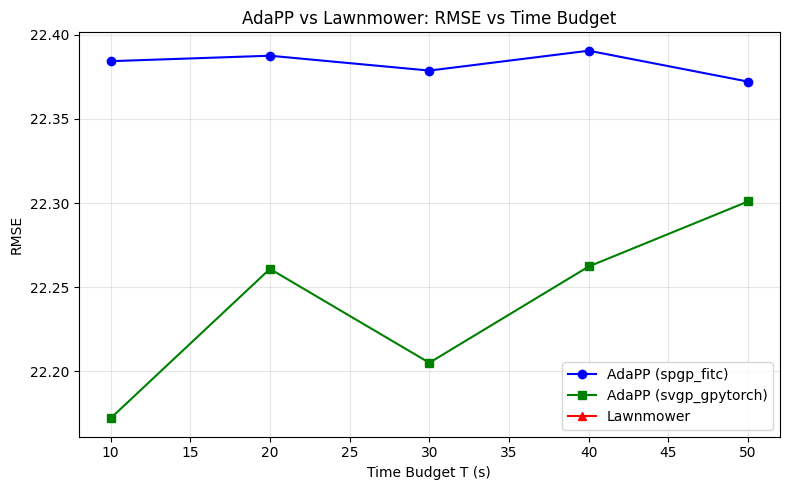

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

for backend, color, marker in [('spgp_fitc', 'blue', 'o'), ('svgp_gpytorch', 'green', 's')]:
    if backend in all_results:
        rmses = [r['rmse'] for r in all_results[backend]['adapp']]
        ax.plot(TIME_BUDGETS, rmses, f'{color[0]}-{marker}', label=f'AdaPP ({backend})', linewidth=1.5)

# Lawnmower (same for both backends).
first_backend = list(all_results.keys())[0]
lm_rmses = [r['rmse'] for r in all_results[first_backend]['lawnmower']]
ax.plot(TIME_BUDGETS, lm_rmses, 'r-^', label='Lawnmower', linewidth=1.5)

ax.set_xlabel('Time Budget T (s)')
ax.set_ylabel('RMSE')
ax.set_title('AdaPP vs Lawnmower: RMSE vs Time Budget')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### 8b. Trajectory on Map (last time budget)

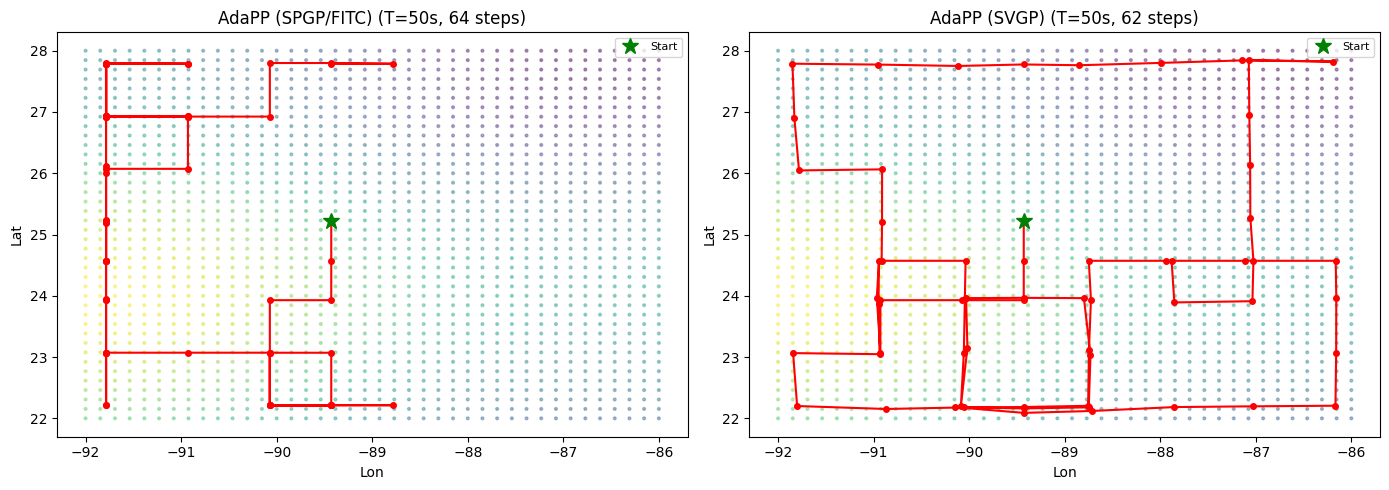

In [9]:
# Show trajectories for the largest time budget.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (backend, label) in zip(axes, [('spgp_fitc', 'AdaPP (SPGP/FITC)'), ('svgp_gpytorch', 'AdaPP (SVGP)')]):
    if backend not in all_results:
        continue
    traj = all_results[backend]['adapp'][-1]['trajectory']
    traj_lats = [t['lat'] for t in traj]
    traj_lons = [t['lon'] for t in traj]

    sc = ax.scatter(eval_lons_flat, eval_lats_flat, c=truth_values, cmap='viridis', s=4, alpha=0.4)
    ax.plot(traj_lons, traj_lats, 'r-o', markersize=4, linewidth=1.5)
    ax.plot(traj_lons[0], traj_lats[0], 'g*', markersize=12, label='Start')
    ax.set_title(f'{label} (T={TIME_BUDGETS[-1]}s, {len(traj)} steps)')
    ax.set_xlabel('Lon'); ax.set_ylabel('Lat')
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

### 8c. Prediction & Error Maps (last budget, SPGP backend)

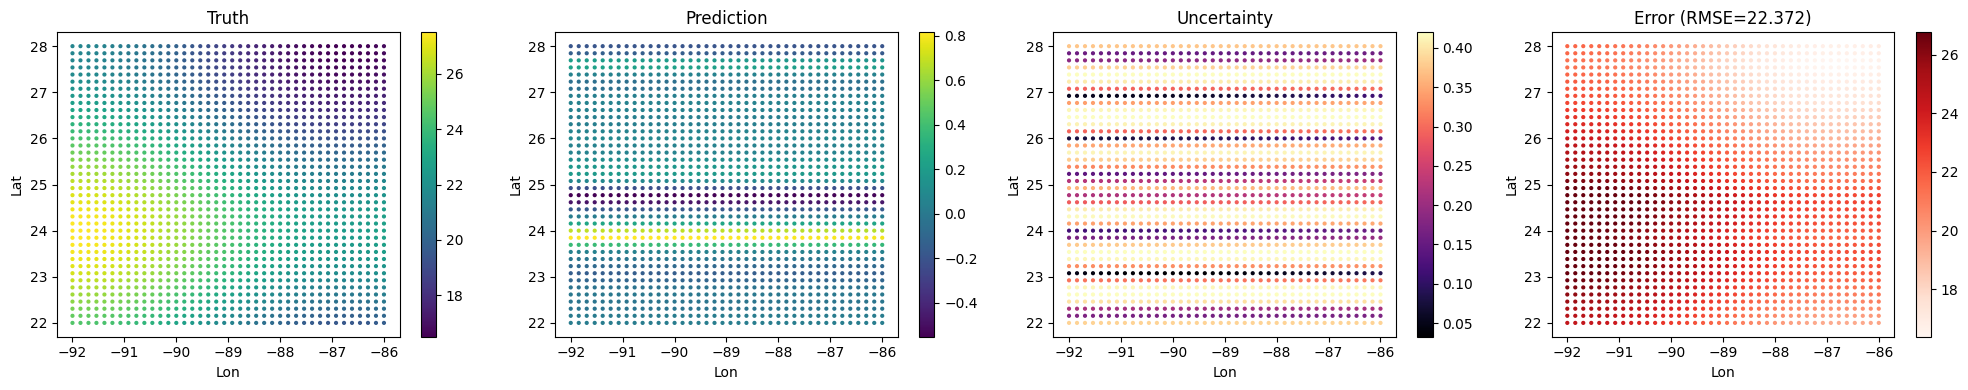

In [10]:
backend = 'spgp_fitc'
last_result = all_results[backend]['adapp'][-1]
obs_data = last_result.get('observations')

if obs_data is not None and obs_data.size >= 3:
    from oceanbench_models.belief.field.spgp_fitc import SPGPFITCFieldModel
    eval_model = SPGPFITCFieldModel({'n_pseudo': N_PSEUDO, 'max_opt_iters': 100, 'include_time': False, 'include_depth': False}, seed=SEED)
    eval_model.fit(obs_data)
    pred_final = eval_model.predict(eval_qp)

    error = np.abs(truth_values - pred_final.mean)
    error_capped = np.minimum(error, np.percentile(error, 95))

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    sc = axes[0].scatter(eval_lons_flat, eval_lats_flat, c=truth_values, cmap='viridis', s=4)
    plt.colorbar(sc, ax=axes[0]); axes[0].set_title('Truth')
    sc = axes[1].scatter(eval_lons_flat, eval_lats_flat, c=pred_final.mean, cmap='viridis', s=4)
    plt.colorbar(sc, ax=axes[1]); axes[1].set_title('Prediction')
    sc = axes[2].scatter(eval_lons_flat, eval_lats_flat, c=pred_final.std, cmap='magma', s=4)
    plt.colorbar(sc, ax=axes[2]); axes[2].set_title('Uncertainty')
    sc = axes[3].scatter(eval_lons_flat, eval_lats_flat, c=error_capped, cmap='Reds', s=4)
    plt.colorbar(sc, ax=axes[3]); axes[3].set_title(f'Error (RMSE={last_result["rmse"]:.3f})')
    for ax in axes:
        ax.set_xlabel('Lon'); ax.set_ylabel('Lat')
    plt.tight_layout(); plt.show()
else:
    print('Not enough observations to produce prediction maps.')

## 9. Save Results

In [11]:
import json

results_dir = ROOT / 'results' / 'adapp_notebook'
results_dir.mkdir(parents=True, exist_ok=True)

summary = {'time_budgets': TIME_BUDGETS}
for backend in all_results:
    summary[f'{backend}_adapp_rmse'] = [r['rmse'] for r in all_results[backend]['adapp']]
    summary[f'{backend}_adapp_mae'] = [r['mae'] for r in all_results[backend]['adapp']]
summary['lawnmower_rmse'] = lm_rmses

with (results_dir / 'summary.json').open('w') as f:
    json.dump(summary, f, indent=2)

print(f'Results saved to {results_dir}')

Results saved to /home/shafezi/Documents/Projects/Data_Provider/oceanbench/results/adapp_notebook
